In [2]:
import pandas as pd
import plotly.express as px

# Load the datasets
sales_by_state = pd.read_csv('datasets/electric_vehicle_sales_by_state.csv')
sales_by_makers = pd.read_csv('datasets/electric_vehicle_sales_by_makers.csv')
dim_date = pd.read_csv('datasets/dim_date.csv')

# Convert 'date' columns to datetime format
sales_by_state['date'] = pd.to_datetime(sales_by_state['date'], format='%d-%b-%y')
sales_by_makers['date'] = pd.to_datetime(sales_by_makers['date'], format='%d-%b-%y')
dim_date['date'] = pd.to_datetime(dim_date['date'], format='%d-%b-%y')

# Merge sales_by_state with dim_date
merged_state_data = pd.merge(sales_by_state, dim_date, on='date')

# Merge sales_by_makers with dim_date
merged_makers_data = pd.merge(sales_by_makers, dim_date, on='date')

# Display the first few rows of the merged dataframes
print(merged_state_data.head())
print(merged_makers_data.head())


        date   state vehicle_category  electric_vehicles_sold  \
0 2021-04-01  Sikkim       2-Wheelers                       0   
1 2021-04-01  Sikkim       4-Wheelers                       0   
2 2021-05-01  Sikkim       2-Wheelers                       0   
3 2021-05-01  Sikkim       4-Wheelers                       0   
4 2021-06-01  Sikkim       2-Wheelers                       0   

   total_vehicles_sold  fiscal_year quarter  
0                  398         2022      Q1  
1                  361         2022      Q1  
2                  113         2022      Q1  
3                   98         2022      Q1  
4                  229         2022      Q1  
        date vehicle_category         maker  electric_vehicles_sold  \
0 2021-04-01       2-Wheelers  OLA ELECTRIC                       0   
1 2022-04-01       2-Wheelers      OKAYA EV                       0   
2 2021-05-01       2-Wheelers  OLA ELECTRIC                       0   
3 2021-06-01       2-Wheelers  OLA ELECTRIC      

In [3]:
# Concatenate the two dataframes
combined_data = pd.concat([merged_state_data, merged_makers_data], axis=0)

# Display the first few rows of the combined dataframe
print(combined_data.head())


        date   state vehicle_category  electric_vehicles_sold  \
0 2021-04-01  Sikkim       2-Wheelers                       0   
1 2021-04-01  Sikkim       4-Wheelers                       0   
2 2021-05-01  Sikkim       2-Wheelers                       0   
3 2021-05-01  Sikkim       4-Wheelers                       0   
4 2021-06-01  Sikkim       2-Wheelers                       0   

   total_vehicles_sold  fiscal_year quarter maker  
0                398.0         2022      Q1   NaN  
1                361.0         2022      Q1   NaN  
2                113.0         2022      Q1   NaN  
3                 98.0         2022      Q1   NaN  
4                229.0         2022      Q1   NaN  


In [4]:
import plotly.express as px

# Aggregate data by date
total_sales_by_date = sales_by_state.groupby('date').sum().reset_index()

# Plot total EV sales over time
fig = px.line(total_sales_by_date, x='date', y='electric_vehicles_sold', title='Total EV Sales Over Time')
fig.show()


In [5]:
# Aggregate data by state, excluding non-numeric columns
sales_by_state_agg = merged_state_data.groupby('state').sum(numeric_only=True).reset_index()

# Plot EV sales by state
fig = px.bar(sales_by_state_agg, x='state', y='electric_vehicles_sold', title='EV Sales by State')
fig.show()


In [6]:
# Calculate penetration rate
merged_state_data['penetration_rate'] = (merged_state_data['electric_vehicles_sold'] / merged_state_data['total_vehicles_sold']) * 100

# Display the first few rows with the new column
print(merged_state_data.head())


        date   state vehicle_category  electric_vehicles_sold  \
0 2021-04-01  Sikkim       2-Wheelers                       0   
1 2021-04-01  Sikkim       4-Wheelers                       0   
2 2021-05-01  Sikkim       2-Wheelers                       0   
3 2021-05-01  Sikkim       4-Wheelers                       0   
4 2021-06-01  Sikkim       2-Wheelers                       0   

   total_vehicles_sold  fiscal_year quarter  penetration_rate  
0                  398         2022      Q1               0.0  
1                  361         2022      Q1               0.0  
2                  113         2022      Q1               0.0  
3                   98         2022      Q1               0.0  
4                  229         2022      Q1               0.0  


In [7]:
# Aggregate data by date
total_sales_by_date = sales_by_state.groupby('date').sum().reset_index()

# Ensure 'date' column is of datetime type
total_sales_by_date['date'] = pd.to_datetime(total_sales_by_date['date'], format='%Y-%m-%d')

# Function to calculate CAGR
def calculate_cagr(end_value, start_value, periods):
    return ((end_value / start_value) ** (1/periods)) - 1

# Calculate start and end values and the number of periods in years
start_value = total_sales_by_date['electric_vehicles_sold'].iloc[0]
end_value = total_sales_by_date['electric_vehicles_sold'].iloc[-1]
periods = (total_sales_by_date['date'].iloc[-1] - total_sales_by_date['date'].iloc[0]).days / 365

# Calculate CAGR
cagr = calculate_cagr(end_value, start_value, periods)
print(f'CAGR: {cagr:.2%}')


CAGR: 188.04%


In [49]:
merged_makers_data

,date,vehicle_category,maker,electric_vehicles_sold,fiscal_year,quarter
0,2021-04-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
1,2022-04-01,2-Wheelers,OKAYA EV,0,2023,Q1
2,2021-05-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
3,2021-06-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
4,2021-07-01,2-Wheelers,OLA ELECTRIC,0,2022,Q2
...,...,...,...,...,...,...
811,2024-03-01,2-Wheelers,BGAUSS,3070,2024,Q4
812,2024-03-01,2-Wheelers,BATTRE ELECTRIC,625,2024,Q4
813,2024-03-01,2-Wheelers,KINETIC GREEN,3915,2024,Q4
814,2024-03-01,2-Wheelers,REVOLT,585,2024,Q4


In [54]:
# 1. Top 3 and Bottom 3 Makers for 2-Wheelers in FY 2023 and 2024

# Assuming fy_2023_2024 is your filtered DataFrame for fiscal years 2023 and 2024
fy_2023_2024 = merged_makers_data[(merged_makers_data['fiscal_year'] == 2023) | (merged_makers_data['fiscal_year'] == 2024)]
fy_2023_2024_2w = fy_2023_2024[fy_2023_2024['vehicle_category'] == '2-Wheelers']

# Sum of electric vehicles sold by maker and fiscal year
makers_sales = fy_2023_2024_2w.groupby(['maker', 'fiscal_year'])['electric_vehicles_sold'].sum().reset_index()

# Top 3 and Bottom 3 Makers for each year
top_bottom_makers = pd.concat([makers_sales.groupby('fiscal_year').apply(lambda x: x.nlargest(3, 'electric_vehicles_sold')).reset_index(drop=True),
                               makers_sales.groupby('fiscal_year').apply(lambda x: x.nsmallest(3, 'electric_vehicles_sold')).reset_index(drop=True)])

# Plot
fig = px.bar(top_bottom_makers, x='maker', y='electric_vehicles_sold', color='fiscal_year',
             title='Top 3 and Bottom 3 Makers for Fiscal Years 2023 and 2024 in Terms of 2-Wheelers Sold',
             labels={'electric_vehicles_sold': 'Electric Vehicles Sold', 'maker': 'Maker'},
             barmode='group')
fig.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_11820\2415721535.py:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Asus\AppData\Local\Temp\ipykernel_11820\2415721535.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [71]:
fy_2024

,date,vehicle_category,maker,electric_vehicles_sold,fiscal_year,quarter
100,2023-04-01,4-Wheelers,Tata Motors,364,2024,Q1
101,2023-04-01,4-Wheelers,MG Motor,265,2024,Q1
102,2023-04-01,4-Wheelers,Mahindra & Mahindra,4880,2024,Q1
103,2023-04-01,4-Wheelers,BYD India,156,2024,Q1
104,2023-04-01,4-Wheelers,Hyundai Motor,42,2024,Q1
...,...,...,...,...,...,...
811,2024-03-01,2-Wheelers,BGAUSS,3070,2024,Q4
812,2024-03-01,2-Wheelers,BATTRE ELECTRIC,625,2024,Q4
813,2024-03-01,2-Wheelers,KINETIC GREEN,3915,2024,Q4
814,2024-03-01,2-Wheelers,REVOLT,585,2024,Q4


In [70]:
# 2. Top 5 States with Highest Penetration Rate in 2-Wheeler and 4-Wheeler EV Sales in FY 2024
# Calculate penetration rate for FY 2024
fy_2024 = merged_makers_data[merged_makers_data['fiscal_year'] == 2024]
fy_2024['penetration_rate'] = (fy_2024['electric_vehicles_sold'] / fy_2024['electric_vehicles_sold']) * 100

# Top 5 states by penetration rate for 2-wheelers and 4-wheelers
top_5_states_2w = fy_2024[fy_2024['vehicle_category'] == '2-Wheelers'].groupby('state')['penetration_rate'].mean().nlargest(5).reset_index()
top_5_states_4w = fy_2024[fy_2024['vehicle_category'] == '4-Wheelers'].groupby('state')['penetration_rate'].mean().nlargest(5).reset_index()

# Plot
fig_2w = px.bar(top_5_states_2w, x='state', y='penetration_rate', 
                title='Top 5 States with the Highest Penetration Rate in 2-Wheeler EV Sales in FY 2024',
                labels={'penetration_rate': 'Penetration Rate (%)', 'state': 'State'})
fig_2w.show()

fig_4w = px.bar(top_5_states_4w, x='state', y='penetration_rate', 
                title='Top 5 States with the Highest Penetration Rate in 4-Wheeler EV Sales in FY 2024',
                labels={'penetration_rate': 'Penetration Rate (%)', 'state': 'State'})
fig_4w.show()


KeyError: 'total_vehicles_sold'

In [10]:
# 3. States with Negative Penetration (Decline) in EV Sales from 2022 to 2024
# Filter data for FY 2022 and FY 2024
filtered_data_2022_2024 = merged_state_data[merged_state_data['fiscal_year'].isin([2022, 2024])]

# Calculate penetration rate
filtered_data_2022_2024['penetration_rate'] = (filtered_data_2022_2024['electric_vehicles_sold'] / filtered_data_2022_2024['total_vehicles_sold']) * 100

# Calculate the difference in penetration rate between FY 2024 and FY 2022 for each state
penetration_diff = filtered_data_2022_2024.pivot_table(index='state', columns='fiscal_year', values='penetration_rate', aggfunc='mean').reset_index()
penetration_diff['penetration_change'] = penetration_diff[2024] - penetration_diff[2022]

# List states with negative penetration change
negative_penetration_states = penetration_diff[penetration_diff['penetration_change'] < 0]['state']

print("States with Negative Penetration in EV Sales from 2022 to 2024:")
print(negative_penetration_states)


States with Negative Penetration in EV Sales from 2022 to 2024:
1     Andaman & Nicobar Island
18                      Ladakh
Name: state, dtype: object


C:\Users\Asus\AppData\Local\Temp\ipykernel_11820\1576646546.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [11]:
df = merged_state_data
df

,date,state,vehicle_category,electric_vehicles_sold,total_vehicles_sold,fiscal_year,quarter,penetration_rate
0,2021-04-01,Sikkim,2-Wheelers,0,398,2022,Q1,0.000000
1,2021-04-01,Sikkim,4-Wheelers,0,361,2022,Q1,0.000000
2,2021-05-01,Sikkim,2-Wheelers,0,113,2022,Q1,0.000000
3,2021-05-01,Sikkim,4-Wheelers,0,98,2022,Q1,0.000000
4,2021-06-01,Sikkim,2-Wheelers,0,229,2022,Q1,0.000000
...,...,...,...,...,...,...,...,...
2440,2024-03-01,Mizoram,2-Wheelers,58,1932,2024,Q4,3.002070
2441,2024-03-01,DNH and DD,2-Wheelers,25,780,2024,Q4,3.205128
2442,2024-03-01,Manipur,2-Wheelers,13,1394,2024,Q4,0.932568
2443,2024-03-01,Andaman & Nicobar Island,2-Wheelers,2,447,2024,Q4,0.447427


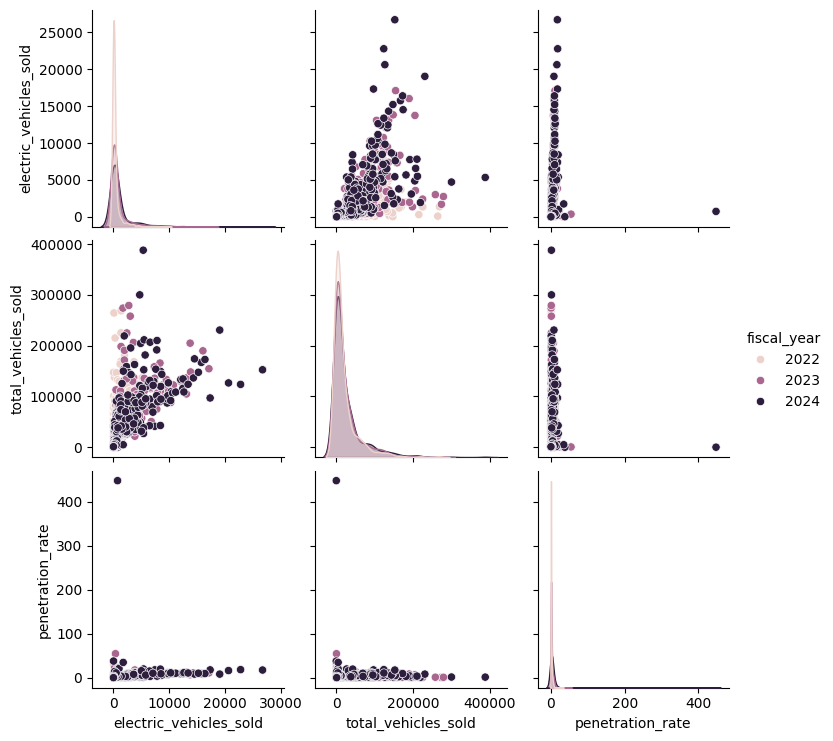

In [12]:
import seaborn as sb
sb.pairplot(df,hue='fiscal_year')

In [13]:
px.scatter_3d(df,x=df['state'],y=df['electric_vehicles_sold'],z=df['vehicle_category'])

Quarterly Trends Based on Sales Volume for Top 5 EV Makers (4-Wheelers) from 2022 to 2024:


<Axes: ylabel='maker'>

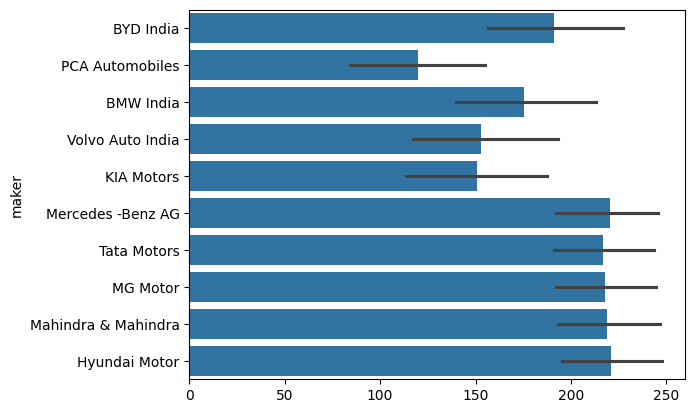

In [24]:
# 4. Quarterly Trends Based on Sales Volume for Top 5 EV Makers (4-Wheelers) from 2022 to 2024

# Filter data for FY 2022 to FY 2024 and for 4-wheelers
filtered_4_wheelers_data = merged_makers_data[(merged_makers_data['fiscal_year'].isin([2022, 2023, 2024])) & (merged_makers_data['vehicle_category'] == '4-Wheelers')]

# Group by maker and sum the electric vehicles sold to identify the top 5 makers
top_5_makers = filtered_4_wheelers_data.groupby('maker')['electric_vehicles_sold'].sum().nlargest(5).index

# Filter data for top 5 makers
top_5_makers_data = filtered_4_wheelers_data[filtered_4_wheelers_data['maker'].isin(top_5_makers)]

# Group by fiscal_year, quarter, and maker, and sum the electric vehicles sold
quarterly_trends = top_5_makers_data.groupby(['fiscal_year', 'quarter', 'maker'])['electric_vehicles_sold'].sum().reset_index()

print("Quarterly Trends Based on Sales Volume for Top 5 EV Makers (4-Wheelers) from 2022 to 2024:")
sb.barplot(filtered_4_wheelers_data['maker'],legend=True)


In [25]:
# 5. EV Sales and Penetration Rates in Delhi vs Karnataka for 2024
# Filter data for FY 2024 and for Delhi and Karnataka
filtered_data_2024 = merged_state_data[(merged_state_data['fiscal_year'] == 2024) & (merged_state_data['state'].isin(['Delhi', 'Karnataka']))]

# Calculate penetration rate
filtered_data_2024['penetration_rate'] = (filtered_data_2024['electric_vehicles_sold'] / filtered_data_2024['total_vehicles_sold']) * 100

# Group by state and vehicle_category, and sum the electric vehicles sold and calculate the mean penetration rate
state_summary = filtered_data_2024.groupby(['state', 'vehicle_category']).agg({
    'electric_vehicles_sold': 'sum',
    'penetration_rate': 'mean'
}).reset_index()

print("EV Sales and Penetration Rates in Delhi vs Karnataka for 2024:")
print(state_summary)


EV Sales and Penetration Rates in Delhi vs Karnataka for 2024:
       state vehicle_category  electric_vehicles_sold  penetration_rate
0      Delhi       2-Wheelers                   38094          9.700033
1      Delhi       4-Wheelers                    8630          4.263585
2  Karnataka       2-Wheelers                  148111         11.510878
3  Karnataka       4-Wheelers                   12878          4.277313


C:\Users\Asus\AppData\Local\Temp\ipykernel_11820\3078391668.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [30]:
# 6. CAGR in 4-Wheeler Units for the Top 5 Makers from 2022 to 2024
# Filter data for 4-wheelers and fiscal years 2022 and 2024
fy_2022_2024_4w = merged_makers_data[(merged_makers_data['fiscal_year'].isin([2022, 2023, 2024])) & 
                                     (merged_makers_data['vehicle_category'] == '4-Wheelers')]

# Group by maker and sum sales
top_5_makers_4w_cagr = fy_2022_2024_4w.groupby('maker')['electric_vehicles_sold'].sum().nlargest(5).reset_index()

# Calculate CAGR for top 5 makers
cagr_results = []

for maker in top_5_makers_4w_cagr['maker']:
    maker_data = fy_2022_2024_4w[fy_2022_2024_4w['maker'] == maker].groupby('fiscal_year')['electric_vehicles_sold'].sum()
    start_value = maker_data.loc[2022]
    end_value = maker_data.loc[2024]
    periods = 2  # From 2022 to 2024

    cagr = calculate_cagr(end_value, start_value, periods)
    cagr_results.append({'maker': maker, 'CAGR': cagr})

print(pd.DataFrame(cagr_results))


                 maker      CAGR
0          Tata Motors  0.947150
1  Mahindra & Mahindra  1.403301
2             MG Motor  1.315309
3            BYD India  5.665151
4        Hyundai Motor  2.554766


In [32]:
# 7. Top 10 States with Highest CAGR in Total Vehicles Sold from 2022 to 2024
# Group by state and fiscal year, sum total vehicles sold
total_vehicles_by_state = filtered_data_2022_2024.groupby(['state', 'fiscal_year'])['total_vehicles_sold'].sum().unstack().reset_index()

# Calculate CAGR for each state
state_cagr_results = []

for index, row in total_vehicles_by_state.iterrows():
    start_value = row[2022]
    end_value = row[2024]
    periods = 2  # From 2022 to 2024

    cagr = calculate_cagr(end_value, start_value, periods)*100
    state_cagr_results.append({'state': row['state'], 'CAGR': cagr})

# Get top 10 states with highest CAGR
top_10_states_cagr = pd.DataFrame(state_cagr_results).nlargest(10, 'CAGR')

print(top_10_states_cagr)


                state       CAGR
22          Meghalaya  28.469075
10                Goa  27.410196
16          Karnataka  25.283582
9               Delhi  22.884347
28          Rajasthan  21.497380
11            Gujarat  20.545677
4               Assam  20.133672
23            Mizoram  18.771599
3   Arunachal Pradesh  18.303359
12            Haryana  17.680434


In [35]:
# 8. Peak and Low Season Months for EV Sales from 2022 to 2024
# Group by month and sum electric vehicles sold
merged_state_data['month'] = merged_state_data['date'].dt.month
monthly_sales = merged_state_data.groupby('month')['electric_vehicles_sold'].sum().reset_index()

# Identify peak and low season months
peak_month = monthly_sales.nlargest(1, 'electric_vehicles_sold')['month'].values[0]
low_month = monthly_sales.nsmallest(1, 'electric_vehicles_sold')['month'].values[0]

print(f'Peak Season Month: {peak_month}')
print(f'Low Season Month: {low_month}')


Peak Season Month: 3
Low Season Month: 6


In [38]:
# 9. Projected Number of EV Sales for Top 10 States by Penetration Rate in 2030
# Calculate CAGR for top 10 states by penetration rate for FY 2024
top_10_states_penetration = filtered_data_2024.groupby('state')['penetration_rate'].mean().nlargest(10).reset_index()

# Calculate projected sales for 2030 using CAGR
projection_results = []

for state in top_10_states_penetration['state']:
    state_data = filtered_data_2022_2024[filtered_data_2022_2024['state'] == state].groupby('fiscal_year')['electric_vehicles_sold'].sum()
    start_value = state_data.loc[2024]
    cagr = calculate_cagr(start_value, state_data.loc[2022], 2)  # From 2022 to 2024
    
    # Projected value for 2030
    projected_value = start_value * ((1 + cagr) ** (2030 - 2024))
    projection_results.append({'state': state, 'Projected Sales in 2030': projected_value})

print(pd.DataFrame(projection_results))


       state  Projected Sales in 2030
0  Karnataka             8.383406e+06
1      Delhi             1.054259e+06


In [41]:
# 10. Revenue Growth Rate of 4-Wheeler and 2-Wheeler EVs for 2022 vs 2024 and 2023 vs 2024
# Assuming average unit prices for 4-wheelers and 2-wheelers
average_price_4w = 1500000  # example value
average_price_2w = 85000   # example value

# Calculate revenue for each year and category
revenue_by_year_category = filtered_data_2022_2024.groupby(['fiscal_year', 'vehicle_category'])['electric_vehicles_sold'].sum().reset_index()

# Calculate revenue growth rates
revenue_growth_results = []

for category in ['4-Wheeler', '2-Wheeler']:
    revenue_2022 = revenue_by_year_category[(revenue_by_year_category['fiscal_year'] == 2022) & 
                                            (revenue_by_year_category['vehicle_category'] == category)]['electric_vehicles_sold'].values[0]
    revenue_2023 = revenue_by_year_category[(revenue_by_year_category['fiscal_year'] == 2023) & 
                                            (revenue_by_year_category['vehicle_category'] == category)]['electric_vehicles_sold'].values[0]
    revenue_2024 = revenue_by_year_category[(revenue_by_year_category['fiscal_year'] == 2024) & 
                                            (revenue_by_year_category['vehicle_category'] == category)]['electric_vehicles_sold'].values[0]

    if category == '4-Wheeler':
        revenue_2022 *= average_price_4w
        revenue_2023 *= average_price_4w
        revenue_2024 *= average_price_4w
    else:
        revenue_2022 *= average_price_2w
        revenue_2023 *= average_price_2w
        revenue_2024 *= average_price_2w

    growth_rate_2022_2024 = (revenue_2024 - revenue_2022) / revenue_2022
    growth_rate_2023_2024 = (revenue_2024 - revenue_2023) / revenue_2023

    revenue_growth_results.append({
        'category': category,
        'growth_rate_2022_2024': growth_rate_2022_2024,
        'growth_rate_2023_2024': growth_rate_2023_2024
    })

print(pd.DataFrame(revenue_growth_results))


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [40]:
filtered_data_2022_2024

,date,state,vehicle_category,electric_vehicles_sold,total_vehicles_sold,fiscal_year,quarter,penetration_rate
0,2021-04-01,Sikkim,2-Wheelers,0,398,2022,Q1,0.000000
1,2021-04-01,Sikkim,4-Wheelers,0,361,2022,Q1,0.000000
2,2021-05-01,Sikkim,2-Wheelers,0,113,2022,Q1,0.000000
3,2021-05-01,Sikkim,4-Wheelers,0,98,2022,Q1,0.000000
4,2021-06-01,Sikkim,2-Wheelers,0,229,2022,Q1,0.000000
...,...,...,...,...,...,...,...,...
2440,2024-03-01,Mizoram,2-Wheelers,58,1932,2024,Q4,3.002070
2441,2024-03-01,DNH and DD,2-Wheelers,25,780,2024,Q4,3.205128
2442,2024-03-01,Manipur,2-Wheelers,13,1394,2024,Q4,0.932568
2443,2024-03-01,Andaman & Nicobar Island,2-Wheelers,2,447,2024,Q4,0.447427
